# Phase 9 — Final Evaluation & Comparison (`EVALUATE_TEST = True`)

The **only** notebook that touches the 15% test set. All 12 models are fit **once on X_train** with configurations
frozen in Phases 6–8 (nothing is chosen, tuned or refit using validation or test). Each one is evaluated on
train / validation / **test**.

| Group | Models (config source) |
|---|---|
| Phase-6 baselines (defaults) | Linear Regression, Ridge α=1, Lasso α=1, ElasticNet α=1/l1=0.5, Decision Tree, Random Forest, Gradient Boosting |
| Phase-7 tuned (CV on train) | Ridge α=15.85, Lasso α=0.00251, ElasticNet α=0.00316/l1=0.99 |
| Phase-8 tuned (random search + repeated-CV guard) | Random Forest, Gradient Boosting |

XGBoost / LightGBM / CatBoost are excluded: they never ran in this project, so no baseline or tuned configuration exists.

**Outputs:** the comparison table `| Model | MAE | MSE | RMSE | R² | CV RMSE |` in ₹; train/val/test RMSE and the
generalization gap; training time; bootstrap 95% CIs on test; and the plots (actual vs predicted, residuals vs predicted,
RMSE/MAE across models, error by rent range).

No data cleaning. Upload `prepared_data.joblib` into the Colab working directory, then *Run all*.

In [1]:
# No extra packages needed: scikit-learn, pandas, numpy, matplotlib and joblib are preinstalled in Colab.

In [2]:
import os, json, time, hashlib, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, RepeatedKFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
EVALUATE_TEST = True                       # Phase 9: the single, final look at the test set
EXPECTED_REFERENCE_ID = "70560d1bd70af7cd" # from phase5_prepare_data.ipynb
CV_FOLDS = 5
N_BOOT = 2000
os.makedirs("outputs", exist_ok=True)

In [3]:
d = joblib.load("prepared_data.joblib")       # numpy arrays + builtins only → loads under any pandas version
if not str(d.get("storage_format", "")).startswith("numpy-v1") or not isinstance(d["X_train"], np.ndarray):
    raise RuntimeError("BUNDLE / NOTEBOOK VERSION MISMATCH — STOP. This notebook expects the numpy-format bundle "
                       "(storage_format 'numpy-v1') written by the current phase5_prepare_data.ipynb. "
                       "Re-upload BOTH the latest prepared_data.joblib and the latest copy of this notebook.")
feature_names = list(d["feature_names"])

def frames_from_bundle(d):
    # Rebuild DataFrames/Series: float64 X, int64 y in rupees, original row ids as index (identical to Phase 5)
    out = {}
    for s in ("train", "val", "test"):
        idx = pd.Index(d[f"index_{s}"], dtype="int64")
        out[f"X_{s}"] = pd.DataFrame(d[f"X_{s}"], columns=feature_names, index=idx)
        out[f"y_{s}"] = pd.Series(d[f"y_{s}"], index=idx, name="Rent")
    return out

f = frames_from_bundle(d)
X_train, X_val, X_test = f["X_train"], f["X_val"], f["X_test"]
y_train, y_val, y_test = f["y_train"], f["y_val"], f["y_test"]
print("Loaded:", X_train.shape, X_val.shape, X_test.shape, "| target_transform:", d["target_transform"])

Loaded: (3313, 34) (711, 34) (711, 34) | target_transform: log1p


In [4]:
def _h(b):
    return hashlib.sha256(b).hexdigest()[:16]

def compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names):
    splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
    ref = {"n_rows": {k: int(len(x)) for k, (x, _) in splits.items()},
           "n_features": len(feature_names),
           "feature_names_hash": _h("|".join(feature_names).encode()),
           "index_hash_sorted": {k: _h(np.sort(x.index.to_numpy("int64")).tobytes()) for k, (x, _) in splits.items()},
           "index_hash_ordered": {k: _h(x.index.to_numpy("int64").tobytes()) for k, (x, _) in splits.items()},
           "target_hash": {k: _h(y.to_numpy("int64").tobytes()) for k, (_, y) in splits.items()}}
    ref["reference_id"] = _h(json.dumps(ref, sort_keys=True).encode())
    content = {k: _h(np.ascontiguousarray(x.to_numpy("float64")).tobytes()) for k, (x, _) in splits.items()}
    return {"reference": ref, "content": content}

fp = compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names)
problems = []
if fp["reference"]["reference_id"] != EXPECTED_REFERENCE_ID:
    problems.append(f"reference_id {fp['reference']['reference_id']} != expected {EXPECTED_REFERENCE_ID}")
if fp["reference"] != d["fingerprint"]["reference"]:
    problems.append("reference fingerprint differs from the bundle's record")
if fp["content"] != d["fingerprint"]["content"]:
    problems.append("X content hash differs from the bundle's record")
if list(X_train.columns) != feature_names or list(X_val.columns) != feature_names or list(X_test.columns) != feature_names:
    problems.append("column order != feature_names")
if d["target_transform"] not in ("log1p", "none"):
    problems.append(f"unknown target_transform {d['target_transform']!r}")
if problems:
    raise RuntimeError("FINGERPRINT MISMATCH — STOP. Do not train.\n  " + "\n  ".join(problems))
print(f"Dataset:  Rows: {len(X_train) + len(X_val) + len(X_test)}  Features: {len(feature_names)}   Fingerprint: OK ({EXPECTED_REFERENCE_ID})")

Dataset:  Rows: 4735  Features: 34   Fingerprint: OK (70560d1bd70af7cd)


## 1. Frozen model configurations (from Phases 6–8)

In [5]:
# Tuned hyperparameters, copied from phase7/outputs/phase7_best_params.json and phase8/outputs/phase8_best_params.json
P7 = {"ridge": {"alpha": 15.848931924611142}, "lasso": {"alpha": 0.002511886431509582},
      "elasticnet": {"alpha": 0.0031622776601683794, "l1_ratio": 0.99}}
P8 = {"random_forest": {"n_estimators": 300, "min_samples_split": 10, "min_samples_leaf": 1, "max_samples": 0.7,
                        "max_features": 1.0, "max_depth": None},
      "gradient_boosting": {"learning_rate": 0.03262161345833058, "loss": "huber", "max_depth": 3, "max_features": 0.5,
                            "min_samples_leaf": 8, "n_estimators": 835, "subsample": 0.6388705975083074}}
# If the JSON files are present (local project layout), assert they match the hard-coded values
for path, hard in (("../phase7/outputs/phase7_best_params.json", P7), ("../phase8/outputs/phase8_best_params.json", P8)):
    if os.path.exists(path):
        saved = json.load(open(path))
        assert saved["reference_id"] == EXPECTED_REFERENCE_ID and all(saved[k] == v for k, v in hard.items()), f"{path} differs"
        print("verified against", path)

def scaled(est):   # linear models: scaler fit on X_train only (re-fit per CV fold)
    return Pipeline([("scaler", StandardScaler()), ("model", est)])
def plain(est):    # tree models: no scaling
    return Pipeline([("model", est)])

L1 = dict(max_iter=100_000, random_state=RANDOM_STATE)
MODELS = {  # name: (group, pipeline)
    "Linear Regression":         ("P6 baseline", scaled(LinearRegression())),
    "Ridge (α=1)":               ("P6 baseline", scaled(Ridge(alpha=1.0))),
    "Lasso (α=1)":               ("P6 baseline", scaled(Lasso(alpha=1.0, **L1))),
    "ElasticNet (α=1)":          ("P6 baseline", scaled(ElasticNet(alpha=1.0, l1_ratio=0.5, **L1))),
    "Decision Tree":             ("P6 baseline", plain(DecisionTreeRegressor(random_state=RANDOM_STATE))),
    "Random Forest (default)":   ("P6 baseline", plain(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))),
    "Gradient Boosting (default)": ("P6 baseline", plain(GradientBoostingRegressor(random_state=RANDOM_STATE))),
    "Ridge (tuned)":             ("P7 tuned", scaled(Ridge(**P7["ridge"]))),
    "Lasso (tuned)":             ("P7 tuned", scaled(Lasso(**P7["lasso"], **L1))),
    "ElasticNet (tuned)":        ("P7 tuned", scaled(ElasticNet(**P7["elasticnet"], **L1))),
    "Random Forest (tuned)":     ("P8 tuned", plain(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **P8["random_forest"]))),
    "Gradient Boosting (tuned)": ("P8 tuned", plain(GradientBoostingRegressor(random_state=RANDOM_STATE, **P8["gradient_boosting"]))),
}
wrap = lambda pipe: TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
print(len(MODELS), "models; target_transform =", d["target_transform"])

verified against ../phase7/outputs/phase7_best_params.json
verified against ../phase8/outputs/phase8_best_params.json
12 models; target_transform = log1p


## 2. Fit once on X_train → predict train / val / test; CV on train

In [6]:
rmse = lambda a, p: float(np.sqrt(mean_squared_error(a, p)))
rmsle = lambda a, p: float(np.sqrt(mean_squared_error(np.log1p(a), np.log1p(np.clip(p, 0, None)))))
def metrics(y, p):
    return {"MAE": mean_absolute_error(y, p), "MSE": mean_squared_error(y, p), "RMSE": rmse(y, p),
            "R2": r2_score(y, p), "RMSLE": rmsle(y, p)}
SCORING = {"rmse": make_scorer(rmse, greater_is_better=False), "mae": make_scorer(mean_absolute_error, greater_is_better=False)}
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rcv = RepeatedKFold(n_splits=CV_FOLDS, n_repeats=3, random_state=RANDOM_STATE)

Y = {"train": y_train, "val": y_val, "test": y_test}
XS = {"train": X_train, "val": X_val, "test": X_test}
results, preds, fitted = {}, {}, {}
for name, (group, pipe) in MODELS.items():
    m = wrap(clone(pipe))
    t0 = time.perf_counter(); m.fit(X_train, y_train); tt = time.perf_counter() - t0
    preds[name] = {s: m.predict(XS[s]) for s in ("train", "val", "test")}
    cvs = cross_validate(wrap(clone(pipe)), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    rcvs = cross_validate(wrap(clone(pipe)), X_train, y_train, cv=rcv, scoring=SCORING, n_jobs=-1)
    results[name] = {"group": group, "train_time_s": tt,
                     **{f"{s}_{k}": v for s in ("train", "val", "test") for k, v in metrics(Y[s], preds[name][s]).items()},
                     "cv_rmse": -cvs["test_rmse"].mean(), "cv_rmse_sd": cvs["test_rmse"].std(), "cv_mae": -cvs["test_mae"].mean(),
                     "repcv_rmse": -rcvs["test_rmse"].mean(), "repcv_mae": -rcvs["test_mae"].mean()}
    fitted[name] = m
    print(f"{name:28s} fit {tt:6.2f}s | val RMSE ₹{results[name]['val_RMSE']:>9,.0f} | test RMSE ₹{results[name]['test_RMSE']:>9,.0f}")
R = pd.DataFrame(results).T
num_cols = [c for c in R.columns if c != "group"]
R[num_cols] = R[num_cols].astype(float)

Linear Regression            fit   0.02s | val RMSE ₹   51,834 | test RMSE ₹   28,487
Ridge (α=1)                  fit   0.01s | val RMSE ₹   51,941 | test RMSE ₹   28,481


Lasso (α=1)                  fit   0.00s | val RMSE ₹   74,205 | test RMSE ₹   55,473
ElasticNet (α=1)             fit   0.00s | val RMSE ₹   72,717 | test RMSE ₹   53,760


Decision Tree                fit   0.03s | val RMSE ₹   55,575 | test RMSE ₹   27,525


Random Forest (default)      fit   0.27s | val RMSE ₹   45,407 | test RMSE ₹   21,791


Gradient Boosting (default)  fit   0.48s | val RMSE ₹   45,882 | test RMSE ₹   22,639
Ridge (tuned)                fit   0.00s | val RMSE ₹   52,760 | test RMSE ₹   28,547
Lasso (tuned)                fit   0.00s | val RMSE ₹   52,888 | test RMSE ₹   28,689


ElasticNet (tuned)           fit   0.00s | val RMSE ₹   52,929 | test RMSE ₹   28,714


Random Forest (tuned)        fit   0.39s | val RMSE ₹   44,780 | test RMSE ₹   22,564


Gradient Boosting (tuned)    fit   2.59s | val RMSE ₹   44,657 | test RMSE ₹   24,588


## 3. Final comparison table (₹, test set)

In [7]:
final = pd.DataFrame({"Group": R["group"], "MAE": R["test_MAE"], "MSE": R["test_MSE"], "RMSE": R["test_RMSE"],
                      "R²": R["test_R2"], "CV RMSE": R["cv_rmse"]}).sort_values("RMSE")
display(final.style.format({"MAE": "₹{:,.0f}", "MSE": "{:.4g}", "RMSE": "₹{:,.0f}", "R²": "{:.4f}", "CV RMSE": "₹{:,.0f}"}))
print("CV RMSE = 5-fold CV on train (seed 42), the same folds as Phases 6–8. For the P8-tuned models it is optimistic, "
      "because the search optimised on these folds; see Rep-CV in the next table.")

,Group,MAE,MSE,RMSE,R²,CV RMSE
Random Forest (default),P6 baseline,"₹9,080",4.748e+08,"₹21,791",0.8358,"₹28,906"
Random Forest (tuned),P8 tuned,"₹9,111",5.091e+08,"₹22,564",0.8239,"₹28,095"
Gradient Boosting (default),P6 baseline,"₹9,443",5.125e+08,"₹22,639",0.8227,"₹28,002"
Gradient Boosting (tuned),P8 tuned,"₹9,668",6.046e+08,"₹24,588",0.7909,"₹26,242"
Decision Tree,P6 baseline,"₹12,265",7.576e+08,"₹27,525",0.7380,"₹38,068"
Ridge (α=1),P6 baseline,"₹10,659",8.111e+08,"₹28,481",0.7195,"₹29,992"
Linear Regression,P6 baseline,"₹10,671",8.115e+08,"₹28,487",0.7193,"₹30,056"
Ridge (tuned),P7 tuned,"₹10,584",8.149e+08,"₹28,547",0.7181,"₹29,787"
Lasso (tuned),P7 tuned,"₹10,565",8.231e+08,"₹28,689",0.7153,"₹29,651"
ElasticNet (tuned),P7 tuned,"₹10,561",8.245e+08,"₹28,714",0.7148,"₹29,645"


CV RMSE = 5-fold CV on train (seed 42), the same folds as Phases 6–8. For the P8-tuned models it is optimistic, because the search optimised on these folds; see Rep-CV in the next table.


In [8]:
gen = pd.DataFrame({"Train RMSE": R["train_RMSE"], "Val RMSE": R["val_RMSE"], "Test RMSE": R["test_RMSE"],
                    "Gen. gap (Test−Train)": R["test_RMSE"] - R["train_RMSE"], "Val−Test Δ": R["val_RMSE"] - R["test_RMSE"],
                    "CV RMSE": R["cv_rmse"], "Rep-CV RMSE (5×3)": R["repcv_rmse"],
                    "Train MAE": R["train_MAE"], "Val MAE": R["val_MAE"], "Test MAE": R["test_MAE"],
                    "Val R²": R["val_R2"], "Test R²": R["test_R2"], "Test RMSLE": R["test_RMSLE"],
                    "Train time (s)": R["train_time_s"]}).loc[final.index]
display(gen.style.format({**{c: "₹{:,.0f}" for c in gen.columns if "RMSE" in c or "MAE" in c or "Δ" in c or "gap" in c},
                          "Val R²": "{:.4f}", "Test R²": "{:.4f}", "Test RMSLE": "{:.4f}", "Train time (s)": "{:.2f}"}))

,Train RMSE,Val RMSE,Test RMSE,Gen. gap (Test−Train),Val−Test Δ,CV RMSE,Rep-CV RMSE (5×3),Train MAE,Val MAE,Test MAE,Val R²,Test R²,Test RMSLE,Train time (s)
Random Forest (default),"₹13,425","₹45,407","₹21,791","₹8,365","₹23,616","₹28,906","₹29,368","₹4,006","₹11,708","₹9,080",0.6071,0.8358,0.3784,0.27
Random Forest (tuned),"₹21,990","₹44,780","₹22,564",₹574,"₹22,216","₹28,095","₹28,427","₹6,911","₹11,543","₹9,111",0.6178,0.8239,0.3721,0.39
Gradient Boosting (default),"₹21,265","₹45,882","₹22,639","₹1,374","₹23,243","₹28,002","₹28,149","₹8,087","₹11,896","₹9,443",0.5988,0.8227,0.3739,0.48
Gradient Boosting (tuned),"₹21,647","₹44,657","₹24,588","₹2,941","₹20,069","₹26,242","₹27,086","₹7,461","₹11,693","₹9,668",0.6199,0.7909,0.3718,2.59
Decision Tree,₹367,"₹55,575","₹27,525","₹27,158","₹28,049","₹38,068","₹38,915",₹17,"₹16,254","₹12,265",0.4114,0.7380,0.4930,0.03
Ridge (α=1),"₹30,035","₹51,941","₹28,481","₹-1,555","₹23,460","₹29,992","₹29,952","₹10,501","₹13,589","₹10,659",0.4858,0.7195,0.3907,0.01
Linear Regression,"₹30,041","₹51,834","₹28,487","₹-1,554","₹23,347","₹30,056","₹29,999","₹10,503","₹13,596","₹10,671",0.4879,0.7193,0.3908,0.02
Ridge (tuned),"₹30,142","₹52,760","₹28,547","₹-1,595","₹24,213","₹29,787","₹29,823","₹10,500","₹13,533","₹10,584",0.4695,0.7181,0.3914,0.00
Lasso (tuned),"₹30,309","₹52,888","₹28,689","₹-1,620","₹24,199","₹29,651","₹29,711","₹10,564","₹13,545","₹10,565",0.4669,0.7153,0.3931,0.00
ElasticNet (tuned),"₹30,328","₹52,929","₹28,714","₹-1,614","₹24,215","₹29,645","₹29,717","₹10,562","₹13,541","₹10,561",0.4661,0.7148,0.3931,0.00


## 4. How certain is the test ranking? Bootstrap 95% CIs (resampling test rows)

In [9]:
rng = np.random.default_rng(RANDOM_STATE)
yt = y_test.to_numpy(); n = len(yt)
B = rng.integers(0, n, size=(N_BOOT, n))
ci_rows = {}
for name in final.index:
    e = yt - preds[name]["test"]
    rm = np.sqrt((e[B] ** 2).mean(axis=1)); ma = np.abs(e[B]).mean(axis=1)
    ci_rows[name] = {"RMSE": rmse(yt, preds[name]["test"]), "RMSE 2.5%": np.percentile(rm, 2.5), "RMSE 97.5%": np.percentile(rm, 97.5),
                     "MAE": mean_absolute_error(yt, preds[name]["test"]), "MAE 2.5%": np.percentile(ma, 2.5), "MAE 97.5%": np.percentile(ma, 97.5)}
CI = pd.DataFrame(ci_rows).T
display(CI.style.format("₹{:,.0f}"))

def paired(a, b):
    ea, eb = yt - preds[a]["test"], yt - preds[b]["test"]
    d_rmse = np.sqrt((ea[B] ** 2).mean(1)) - np.sqrt((eb[B] ** 2).mean(1))
    d_mae = np.abs(ea[B]).mean(1) - np.abs(eb[B]).mean(1)
    return {"pair": f"{a}  vs  {b}", "ΔRMSE": rmse(yt, preds[a]["test"]) - rmse(yt, preds[b]["test"]),
            "ΔRMSE 95% CI": f"[{np.percentile(d_rmse, 2.5):,.0f}, {np.percentile(d_rmse, 97.5):,.0f}]",
            "P(a better on RMSE)": (d_rmse < 0).mean(),
            "ΔMAE": mean_absolute_error(yt, preds[a]["test"]) - mean_absolute_error(yt, preds[b]["test"]),
            "ΔMAE 95% CI": f"[{np.percentile(d_mae, 2.5):,.0f}, {np.percentile(d_mae, 97.5):,.0f}]",
            "P(a better on MAE)": (d_mae < 0).mean()}
pairs = [("Gradient Boosting (tuned)", "Random Forest (tuned)"), ("Gradient Boosting (tuned)", "Gradient Boosting (default)"),
         ("Random Forest (tuned)", "Random Forest (default)"), ("Gradient Boosting (tuned)", "Lasso (tuned)"),
         ("Lasso (tuned)", "Linear Regression")]
display(pd.DataFrame([paired(a, b) for a, b in pairs]).set_index("pair").round(3))
print("Paired bootstrap: the same resampled test rows for both models; a CI excluding 0 means a reliable difference.")

,RMSE,RMSE 2.5%,RMSE 97.5%,MAE,MAE 2.5%,MAE 97.5%
Random Forest (default),"₹21,791","₹16,398","₹27,487","₹9,080","₹7,715","₹10,629"
Random Forest (tuned),"₹22,564","₹16,284","₹29,375","₹9,111","₹7,711","₹10,762"
Gradient Boosting (default),"₹22,639","₹17,557","₹28,128","₹9,443","₹8,002","₹11,081"
Gradient Boosting (tuned),"₹24,588","₹17,916","₹32,015","₹9,668","₹8,142","₹11,440"
Decision Tree,"₹27,525","₹21,685","₹33,657","₹12,265","₹10,579","₹14,191"
Ridge (α=1),"₹28,481","₹19,719","₹37,904","₹10,659","₹8,891","₹12,792"
Linear Regression,"₹28,487","₹19,729","₹37,845","₹10,671","₹8,897","₹12,811"
Ridge (tuned),"₹28,547","₹19,344","₹38,595","₹10,584","₹8,832","₹12,755"
Lasso (tuned),"₹28,689","₹19,181","₹38,944","₹10,565","₹8,805","₹12,781"
ElasticNet (tuned),"₹28,714","₹19,169","₹39,034","₹10,561","₹8,792","₹12,771"


,ΔRMSE,ΔRMSE 95% CI,P(a better on RMSE),ΔMAE,ΔMAE 95% CI,P(a better on MAE)
pair,,,,,,
Gradient Boosting (tuned) vs Random Forest (tuned),2023.694,"[-331, 4,564]",0.052,556.998,"[20, 1,244]",0.021
Gradient Boosting (tuned) vs Gradient Boosting (default),1948.804,"[-648, 4,907]",0.107,224.757,"[-191, 702]",0.156
Random Forest (tuned) vs Random Forest (default),773.356,"[-2,961, 4,512]",0.331,30.859,"[-506, 510]",0.427
Gradient Boosting (tuned) vs Lasso (tuned),-4101.391,"[-7,967, 189]",0.966,-897.330,"[-1,763, -74]",0.983
Lasso (tuned) vs Linear Regression,202.250,"[-1,795, 1,677]",0.415,-105.872,"[-446, 187]",0.754


Paired bootstrap: the same resampled test rows for both models; a CI excluding 0 means a reliable difference.


In [10]:
# Tail sensitivity on test: share of squared error carried by the single worst row
tail = {}
for name in final.index:
    e = yt - preds[name]["test"]; se = e ** 2; k = np.argmax(se)
    tail[name] = {"Test RMSE": np.sqrt(se.mean()), "worst-row share of SSE": se[k] / se.sum(),
                  "Test RMSE w/o worst row": np.sqrt(np.delete(se, k).mean()), "worst row actual ₹": yt[k],
                  "worst row predicted ₹": preds[name]["test"][k], "median |% error|": np.median(np.abs(e) / yt)}
display(pd.DataFrame(tail).T.loc[final.index].style.format({"Test RMSE": "₹{:,.0f}", "Test RMSE w/o worst row": "₹{:,.0f}",
        "worst row actual ₹": "₹{:,.0f}", "worst row predicted ₹": "₹{:,.0f}", "worst-row share of SSE": "{:.3f}",
        "median |% error|": "{:.1%}"}))

,Test RMSE,worst-row share of SSE,Test RMSE w/o worst row,worst row actual ₹,worst row predicted ₹,median |% error|
Random Forest (default),"₹21,791",0.178,"₹19,767","₹380,000","₹134,673",21.9%
Random Forest (tuned),"₹22,564",0.236,"₹19,731","₹700,000","₹407,479",20.9%
Gradient Boosting (default),"₹22,639",0.145,"₹20,954","₹700,000","₹470,518",21.7%
Gradient Boosting (tuned),"₹24,588",0.248,"₹21,342","₹700,000","₹373,759",21.0%
Decision Tree,"₹27,525",0.167,"₹25,138","₹350,000","₹650,000",28.6%
Ridge (α=1),"₹28,481",0.304,"₹23,783","₹700,000","₹281,529",23.0%
Linear Regression,"₹28,487",0.300,"₹23,855","₹700,000","₹284,142",22.8%
Ridge (tuned),"₹28,547",0.331,"₹23,371","₹700,000","₹262,268",22.7%
Lasso (tuned),"₹28,689",0.339,"₹23,349","₹700,000","₹254,894",22.6%
ElasticNet (tuned),"₹28,714",0.340,"₹23,342","₹700,000","₹253,506",22.8%


## 5. Error by rent range (test; low / medium / high = rent terciles)

In [11]:
band = pd.qcut(y_test, 3, labels=["low", "medium", "high"])
edges = pd.qcut(y_test, 3).cat.categories
print("Tercile ranges (₹):", [f"{int(i.left):,}–{int(i.right):,}" for i in edges])
by_band = {}
for name in final.index:
    e = pd.Series(yt - preds[name]["test"], index=y_test.index)
    g = pd.DataFrame({"abs": e.abs(), "pct": (e.abs() / y_test), "sq": e ** 2}).groupby(band, observed=True)
    by_band[name] = pd.concat({"MAE": g["abs"].mean(), "RMSE": np.sqrt(g["sq"].mean()), "MAPE": g["pct"].mean()})
BB = pd.DataFrame(by_band).T
display(BB.style.format({c: ("{:.1%}" if c[0] == "MAPE" else "₹{:,.0f}") for c in BB.columns}))

Tercile ranges (₹): ['2,999–12,000', '12,000–25,000', '25,000–700,000']


## 6. Plots

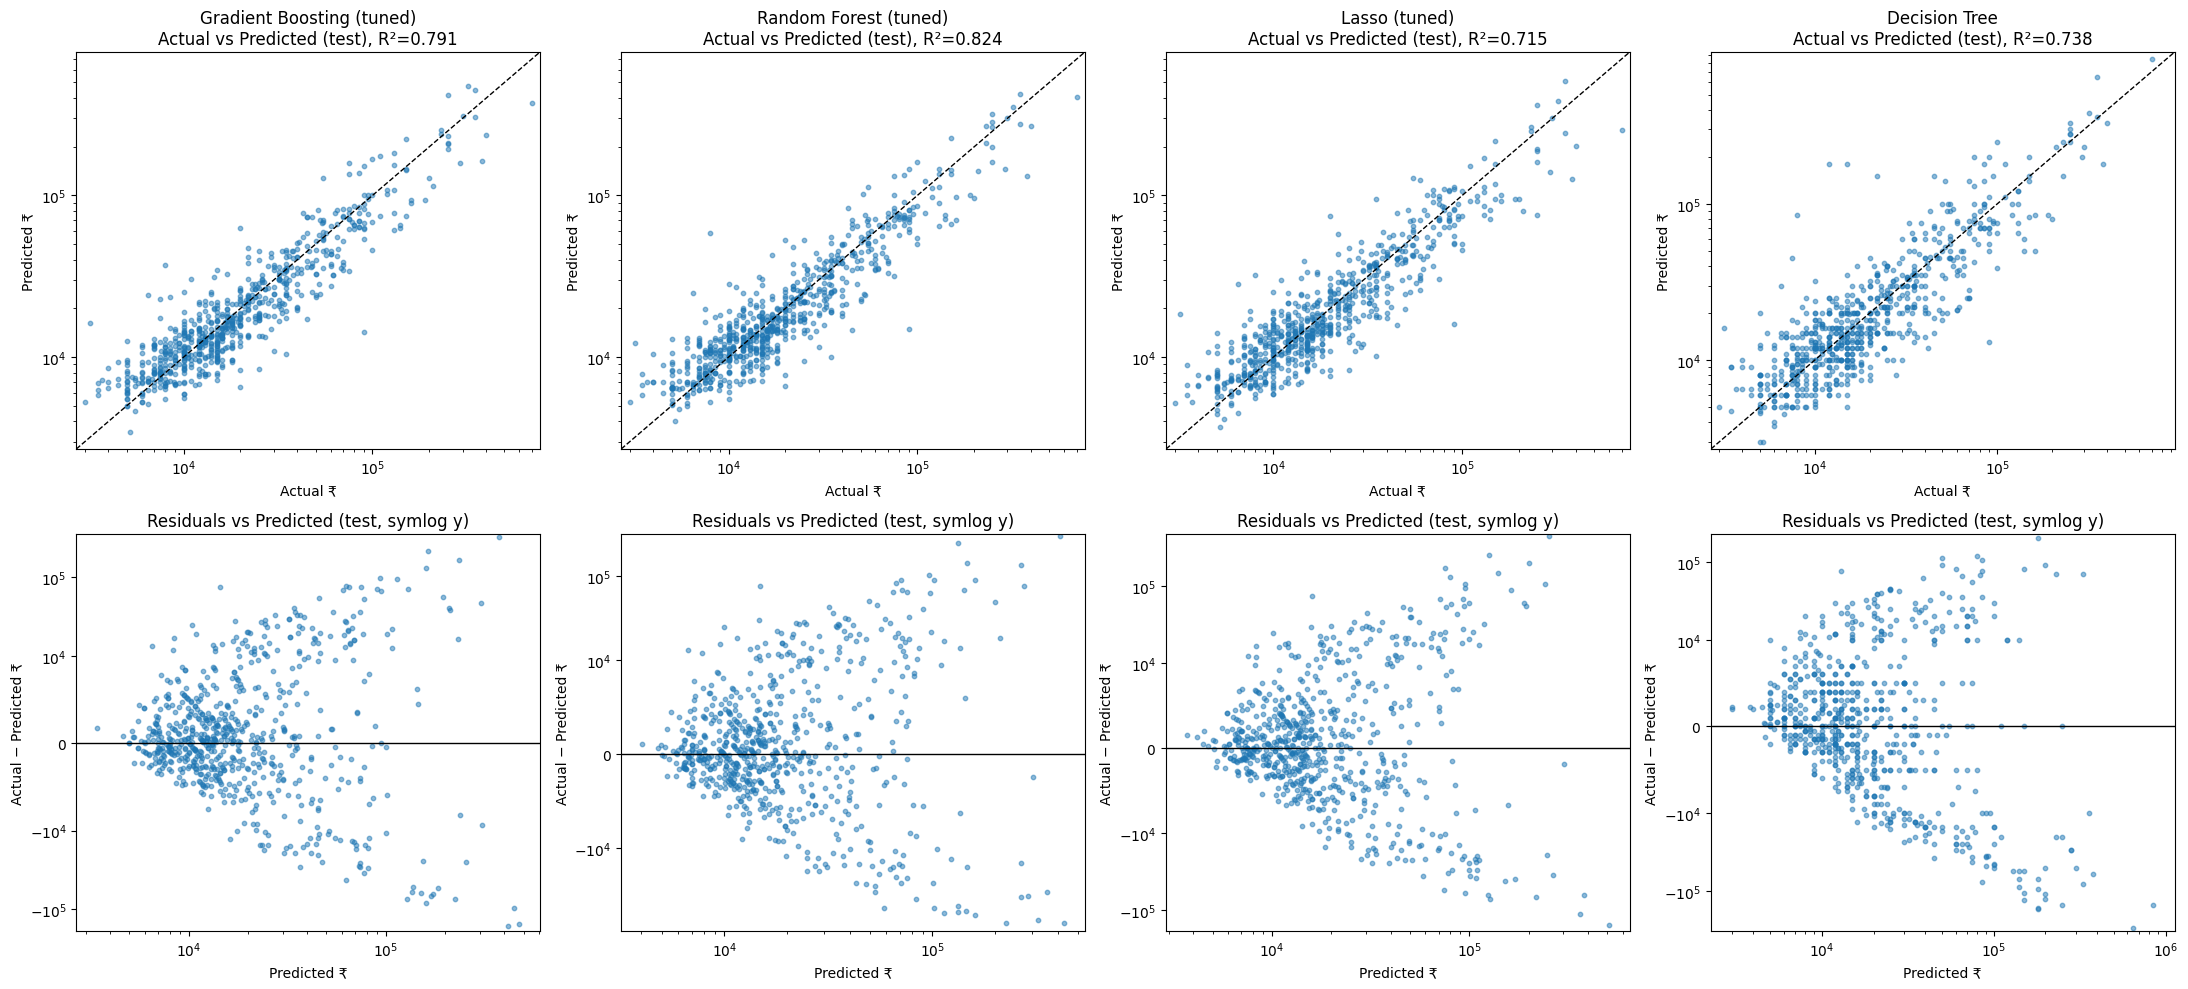

In [12]:
show = ["Gradient Boosting (tuned)", "Random Forest (tuned)", "Lasso (tuned)", "Decision Tree"]
fig, ax = plt.subplots(2, 4, figsize=(22, 10))
for j, name in enumerate(show):
    p = preds[name]["test"]; lim = [min(yt.min(), p.min()) * .9, max(yt.max(), p.max()) * 1.1]
    ax[0, j].scatter(yt, p, s=10, alpha=.5); ax[0, j].plot(lim, lim, "k--", lw=1)
    ax[0, j].set_xscale("log"); ax[0, j].set_yscale("log"); ax[0, j].set_xlim(lim); ax[0, j].set_ylim(lim)
    ax[0, j].set_title(f"{name}\nActual vs Predicted (test), R²={r2_score(yt, p):.3f}"); ax[0, j].set_xlabel("Actual ₹"); ax[0, j].set_ylabel("Predicted ₹")
    ax[1, j].scatter(p, yt - p, s=10, alpha=.5); ax[1, j].axhline(0, color="k", lw=1); ax[1, j].set_xscale("log")
    ax[1, j].set_symlog = None; ax[1, j].set_yscale("symlog", linthresh=10_000)
    ax[1, j].set_title("Residuals vs Predicted (test, symlog y)"); ax[1, j].set_xlabel("Predicted ₹"); ax[1, j].set_ylabel("Actual − Predicted ₹")
plt.tight_layout(); plt.show()

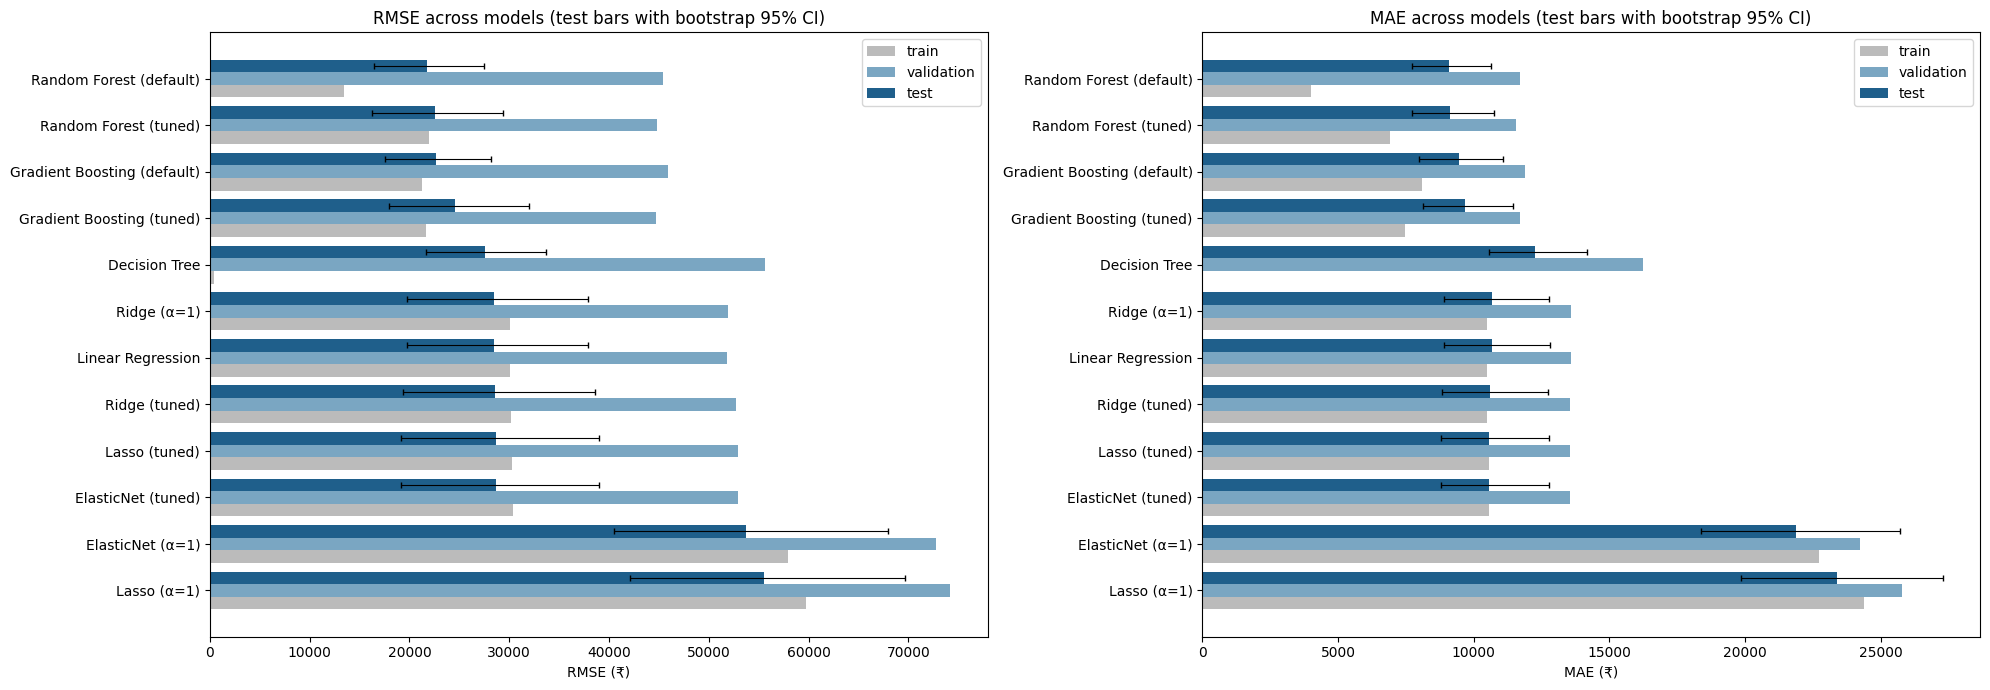

In [13]:
order = final.index[::-1]
fig, ax = plt.subplots(1, 2, figsize=(20, 7))
yy = np.arange(len(order)); h = .27
for a, m in zip(ax, ["RMSE", "MAE"]):
    a.barh(yy - h, R.loc[order, f"train_{m}"], h, label="train", color="#bbbbbb")
    a.barh(yy, R.loc[order, f"val_{m}"], h, label="validation", color="#7aa6c2")
    a.barh(yy + h, R.loc[order, f"test_{m}"], h, label="test", color="#1f5f8b")
    if m == "RMSE":
        a.errorbar(CI.loc[order, "RMSE"], yy + h, xerr=[CI.loc[order, "RMSE"] - CI.loc[order, "RMSE 2.5%"],
                   CI.loc[order, "RMSE 97.5%"] - CI.loc[order, "RMSE"]], fmt="none", ecolor="k", capsize=2, lw=.8)
    else:
        a.errorbar(CI.loc[order, "MAE"], yy + h, xerr=[CI.loc[order, "MAE"] - CI.loc[order, "MAE 2.5%"],
                   CI.loc[order, "MAE 97.5%"] - CI.loc[order, "MAE"]], fmt="none", ecolor="k", capsize=2, lw=.8)
    a.set_yticks(yy, order); a.set_xlabel(f"{m} (₹)"); a.set_title(f"{m} across models (test bars with bootstrap 95% CI)"); a.legend()
plt.tight_layout(); plt.show()

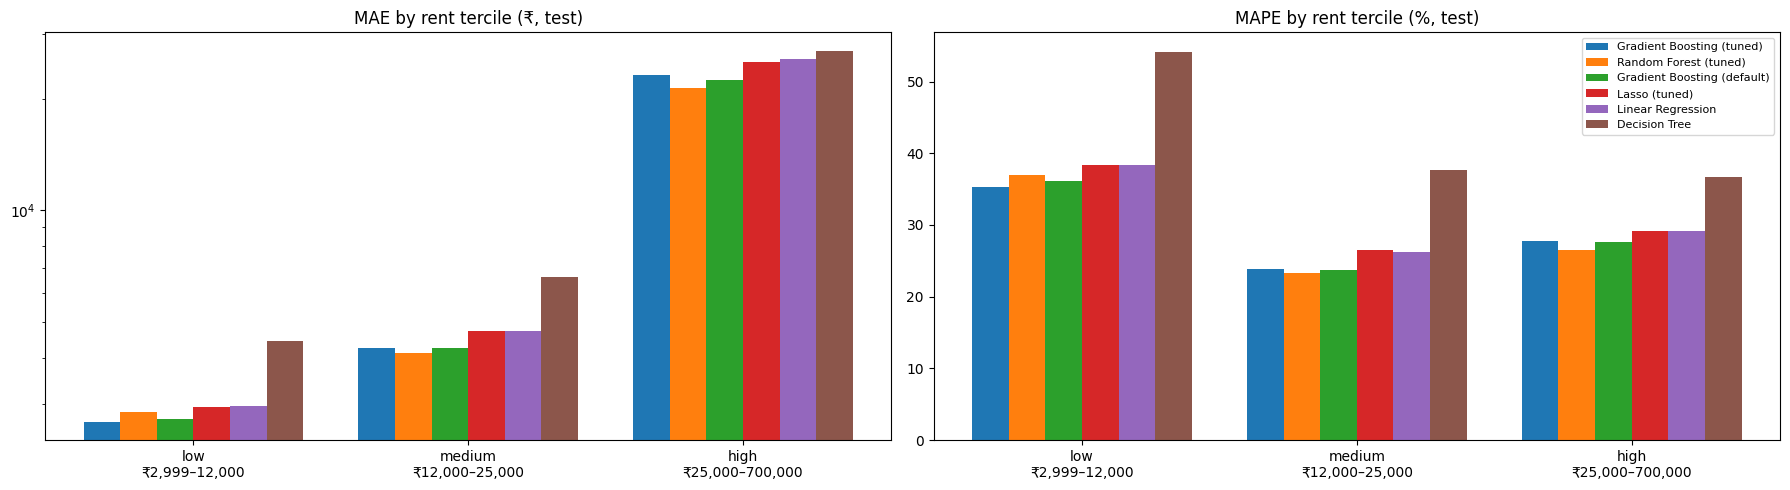

In [14]:
top = ["Gradient Boosting (tuned)", "Random Forest (tuned)", "Gradient Boosting (default)", "Lasso (tuned)", "Linear Regression", "Decision Tree"]
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
x = np.arange(3); w = .8 / len(top)
for i, name in enumerate(top):
    ax[0].bar(x + i * w, BB.loc[name, "MAE"].values, w, label=name)
    ax[1].bar(x + i * w, BB.loc[name, "MAPE"].values * 100, w, label=name)
for a, t in zip(ax, ["MAE by rent tercile (₹, test)", "MAPE by rent tercile (%, test)"]):
    a.set_xticks(x + w * (len(top) - 1) / 2, [f"{b}\n₹{int(i.left):,}–{int(i.right):,}" for b, i in zip(["low", "medium", "high"], edges)])
    a.set_title(t)
ax[0].set_yscale("log"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Save outputs

In [15]:
final.to_csv("outputs/phase9_final_table.csv")
gen.to_csv("outputs/phase9_generalization.csv")
CI.to_csv("outputs/phase9_test_bootstrap_ci.csv")
BB.to_csv("outputs/phase9_error_by_rent_band.csv")
R.to_csv("outputs/phase9_all_metrics.csv")
for name in MODELS:
    key = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("α=", "alpha").replace("=", "")
    pd.concat([pd.DataFrame({"row_id": XS[s].index, "split": s, "actual_rent": Y[s].to_numpy(),
                             "predicted_rent": preds[name][s], "residual": Y[s].to_numpy() - preds[name][s]})
               for s in ("train", "val", "test")]).to_csv(f"outputs/predictions_phase9_{key}.csv", index=False)
print("Saved:", sorted(os.listdir("outputs")))

Saved: ['phase9_all_metrics.csv', 'phase9_error_by_rent_band.csv', 'phase9_final_table.csv', 'phase9_generalization.csv', 'phase9_test_bootstrap_ci.csv', 'predictions_phase9_decision_tree.csv', 'predictions_phase9_elasticnet_alpha1.csv', 'predictions_phase9_elasticnet_tuned.csv', 'predictions_phase9_gradient_boosting_default.csv', 'predictions_phase9_gradient_boosting_tuned.csv', 'predictions_phase9_lasso_alpha1.csv', 'predictions_phase9_lasso_tuned.csv', 'predictions_phase9_linear_regression.csv', 'predictions_phase9_random_forest_default.csv', 'predictions_phase9_random_forest_tuned.csv', 'predictions_phase9_ridge_alpha1.csv', 'predictions_phase9_ridge_tuned.csv']



## 8. Phase-9 findings (test set opened once; nothing was re-selected or refit on it)

### Final comparison (test, ₹; sorted by test RMSE)
| Model | MAE | MSE | RMSE (95% CI) | R² | CV RMSE |
|---|---|---|---|---|---|
| Random Forest (default) | 9,080 | 4.75e8 | **21,791** (16.4k–27.5k) | **0.836** | 28,906 |
| Random Forest (tuned) | 9,111 | 5.09e8 | 22,564 (16.3k–29.4k) | 0.824 | 28,095* |
| Gradient Boosting (default) | 9,443 | 5.13e8 | 22,639 (17.6k–28.1k) | 0.823 | 28,002 |
| Gradient Boosting (tuned) | 9,668 | 6.05e8 | 24,588 (17.9k–32.0k) | 0.791 | 26,242* |
| Decision Tree | 12,265 | 7.58e8 | 27,525 | 0.738 | 38,068 |
| Ridge (α=1) / OLS | 10,659 / 10,671 | 8.11e8 | 28,481 / 28,487 | 0.720 | 29,992 / 30,056 |
| Ridge / Lasso / ElasticNet (tuned) | 10,584 / 10,565 / 10,561 | ≈8.2e8 | 28,547 / 28,689 / 28,714 | 0.715–0.718 | 29,645–29,787 |
| ElasticNet / Lasso (α=1) | 21,866 / 23,373 | ≈3e9 | 53,760 / 55,473 | ≈0 | 57,448 / 59,321 |

\*Optimistic: these are the folds the Phase-8 search optimised on. On repeated CV they are RF tuned ₹28,427 and GB tuned ₹27,086.

### Findings
1. **The ensembles win, and that result is robust.** All four RF/GB variants beat every linear model and the single tree on test RMSE, MAE and R². GB tuned vs Lasso tuned: MAE −₹897, paired-bootstrap CI [−1,763, −74], P = 0.98. Test R² is 0.79–0.84 for the ensembles against 0.715–0.72 for the linear models.
2. **The Phase-8 favourite (GB tuned) is *not* the test winner, but the top four cannot be told apart on RMSE.** GB tuned vs RF tuned: ΔRMSE +₹2,024, CI [−331, 4,564]. Each model's test-RMSE CI is about ±₹6k wide. On **MAE**, RF tuned beats GB tuned by ₹557, CI [20, 1,244]: a small but just-reliable difference.
3. **The 3–4% CV gains from tuning did not show up on test.** RF tuned vs default: +₹773 RMSE (CI includes 0). GB tuned vs default: +₹1,949, CI [−648, 4,907], P(tuned better) = 0.11. The tuning effect is smaller than the test set's sampling noise (711 rows, heavy tail). Neither tuned model is reliably worse than its default either.
4. **Why GB tuned slips: the Huber loss trades the expensive tail for the bulk.** It has the **best low-tercile MAE** (₹2,688) and is about level on the middle tercile. In the **high tercile** (₹25k–₹7L) its MAE is ₹23.2k against RF's ₹21.0–21.4k, and its RMSE is ₹43.1k against ₹37.8–39.4k. Its worst test row (actual ₹7,00,000) is predicted at ₹3.74L and carries 25% of its test squared error. Huber down-weighted exactly those rows in training, and the test set happens to hold several of them.
5. **Tuning bought generalization for RF.** RF tuned has the smallest Test−Train gap of any model (₹574), against ₹8,365 for RF default and ₹27,158 for the Decision Tree, which memorised the training set (train RMSE ₹367).
6. **Validation (≈₹45k) vs test (≈₹22k) RMSE is a split-composition effect, not a leak or a bug.** Validation holds a genuine ₹12,00,000 listing (40–46% of every model's validation SSE); the test maximum is ₹7,00,000. MAE is similar across the two splits (val ₹11.5–11.9k vs test ₹9.1–9.7k for the ensembles), and the model ranking by MAE is consistent.
7. **Linear models:** tuning made no difference on test (Lasso vs OLS, CI includes 0), as Phase 7 predicted. Their limit is bias, especially in the high tercile (MAE ≈ ₹25.3k). Lasso/ElasticNet at α=1 remain degenerate (R² ≈ 0).
8. **Error profile of the best models:** median absolute % error about 21%. MAE is ₹2.7–3.0k for rents up to ₹12k, ₹4.1–4.2k for ₹12–25k, and ₹21–23k above ₹25k. The high tercile drives almost all of the RMSE.

### Inputs to Phase 10
* The test set has now been used. **Picking the final model by test rank alone would turn the test set into a selection set.** Phase 10 should weigh the pre-registered evidence (CV, repeated CV, validation) alongside test, robustness, generalization gap, cost and interpretability.
* Prediction outputs (train/val/test for all 12 models), metric tables, bootstrap CIs and error-by-band are saved in `outputs/`.
